In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_palette("Set2")

In [2]:
df = pd.read_csv("../data/processed/fraud_detection_cleaned.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000000, 32)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,34.0,25.0,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163.0,1,BC,0,1,9.0,0,1500.0,0,INTERNET,16.224843,linux,1,1.0,0,0
1,0,0.8,0.617426,34.0,89.0,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154.0,1,BC,1,1,2.0,0,1500.0,0,INTERNET,3.363854,other,1,1.0,0,0
2,0,0.8,0.996707,9.0,14.0,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89.0,1,BC,0,1,30.0,0,200.0,0,INTERNET,22.730559,windows,0,1.0,0,0
3,0,0.6,0.475100,11.0,14.0,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90.0,1,BC,0,1,1.0,0,200.0,0,INTERNET,15.215816,linux,1,1.0,0,0
4,0,0.9,0.842307,34.0,29.0,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91.0,0,BC,1,1,26.0,0,200.0,0,INTERNET,3.743048,other,0,1.0,0,0


In [3]:
print("Shape :", df.shape)       #dataset overview
print("\nRows :", df.shape[0])
print("\nColumns :", df.shape[1])
df.info()

Shape : (1000000, 32)

Rows : 1000000

Columns : 32
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  float64
 4   current_address_months_count      1000000 non-null  float64
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  str    
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 1

In [ ]:
df.describe().T         #statistical summary 

,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,41.670768,36.146230,5.000000e+00,34.000000,34.000000,34.000000,383.000000
current_address_months_count,1000000.0,86.817583,88.248728,0.000000e+00,20.000000,53.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


In [5]:
df.describe(include="object").T     #categorical features

,count,unique,top,freq
payment_type,1000000,5,AB,370554
employment_status,1000000,7,CA,730252
housing_status,1000000,7,BC,372143
source,1000000,2,INTERNET,992952
device_os,1000000,5,other,342728


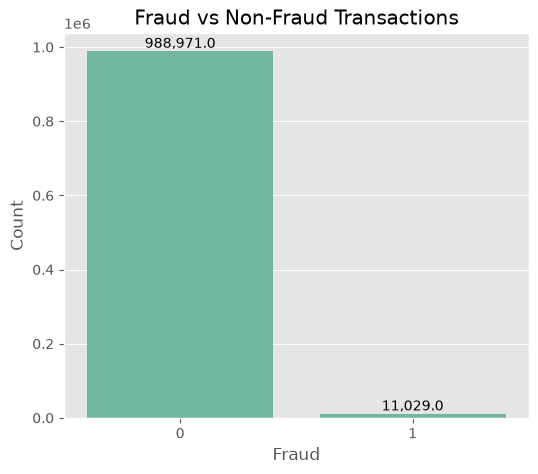

In [6]:
plt.figure(figsize=(6,5))      #Fraud Distribution (Target Variable)
ax = sns.countplot(x="fraud_bool", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',(p.get_x()+p.get_width()/2, p.get_height()),ha='center',va='bottom')
plt.show()

In [7]:
fraud_percentage = df["fraud_bool"].value_counts(normalize=True)*100
fraud_percentage

fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64

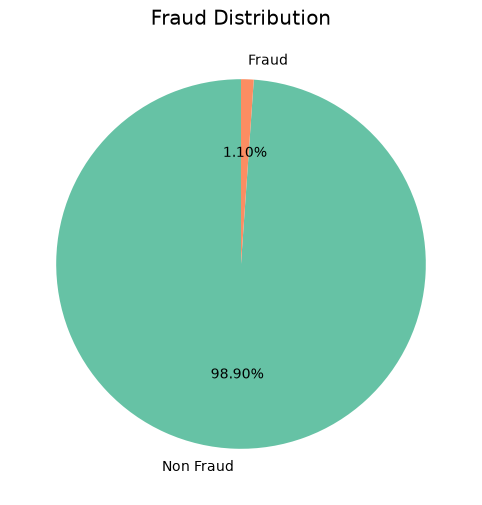

In [8]:
plt.figure(figsize=(6,6))
plt.pie(df["fraud_bool"].value_counts(),labels=["Non Fraud","Fraud"],autopct="%1.2f%%",
        startangle=90)
plt.title("Fraud Distribution")
plt.show()

In [9]:
num_cols = df.select_dtypes(include=np.number).columns
print(num_cols)

Index(['fraud_bool', 'income', 'name_email_similarity',
       'prev_address_months_count', 'current_address_months_count',
       'customer_age', 'days_since_request', 'intended_balcon_amount',
       'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w',
       'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w',
       'credit_risk_score', 'email_is_free', 'phone_home_valid',
       'phone_mobile_valid', 'bank_months_count', 'has_other_cards',
       'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes',
       'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count',
       'month'],
      dtype='str')


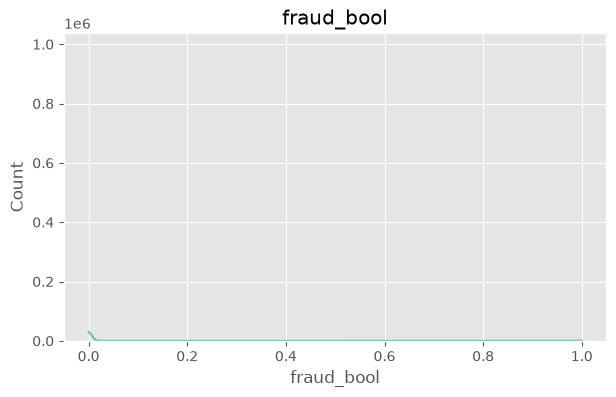

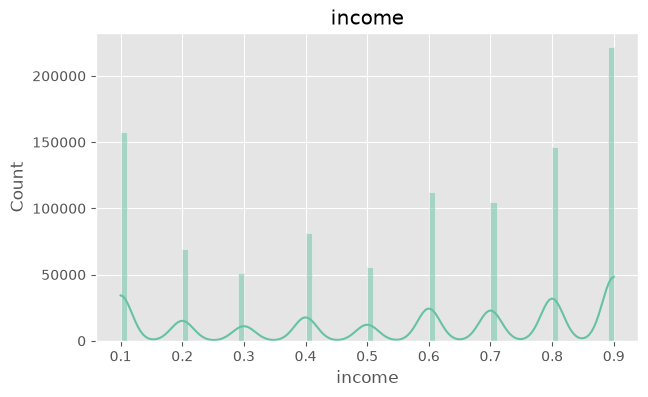

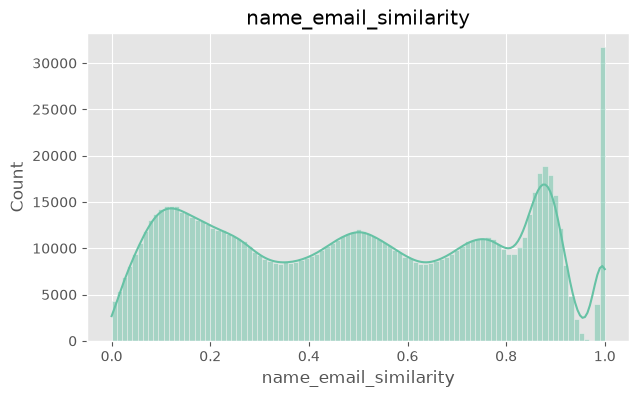

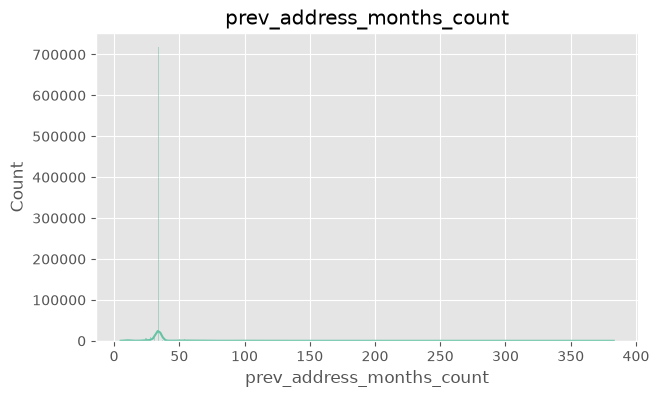

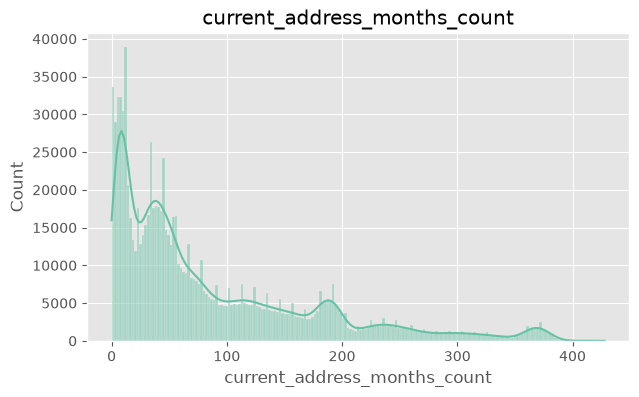

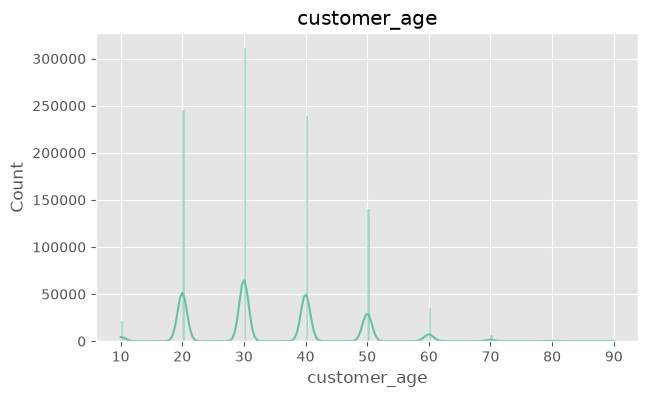

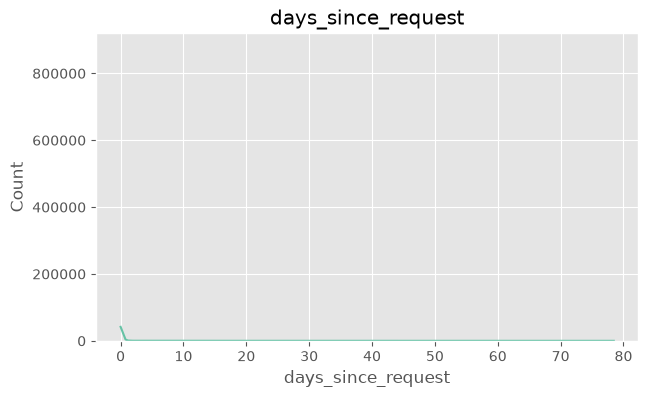

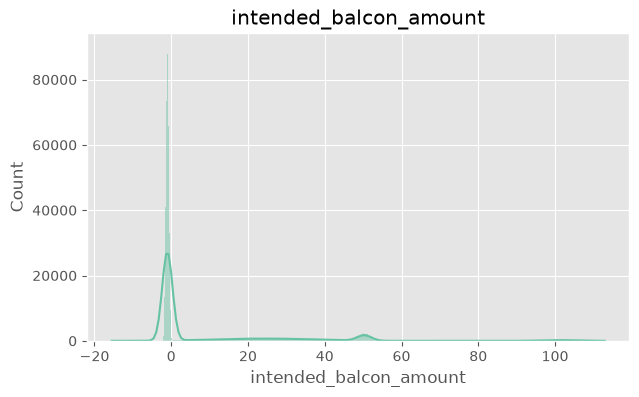

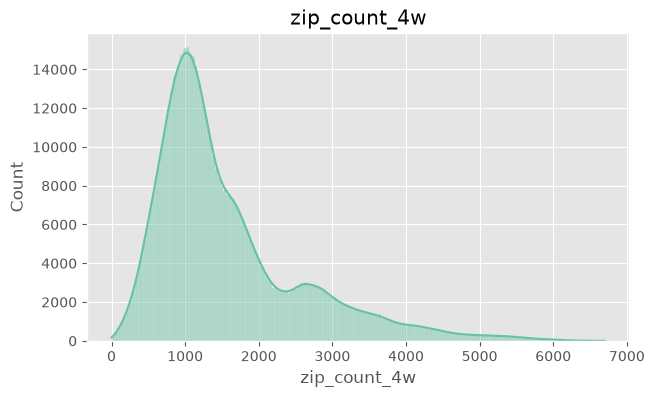

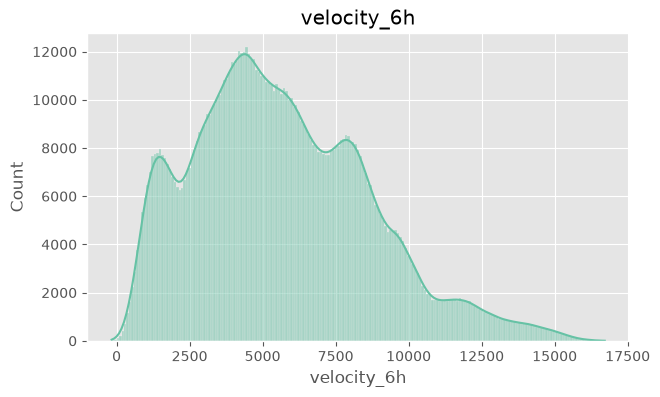

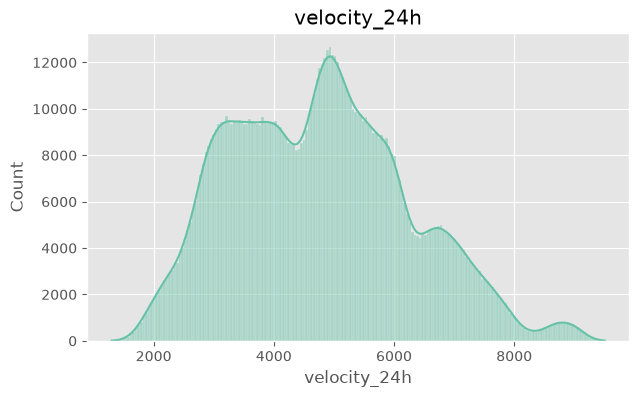

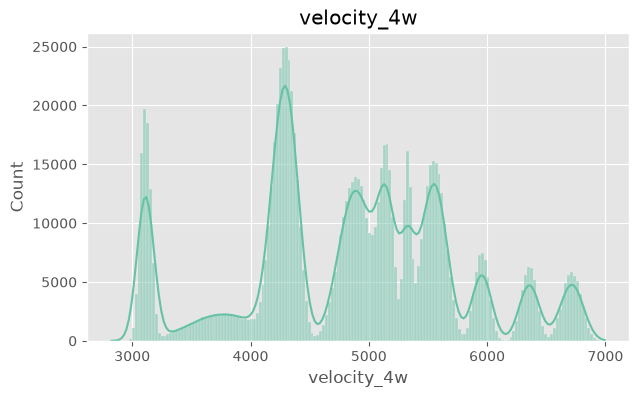

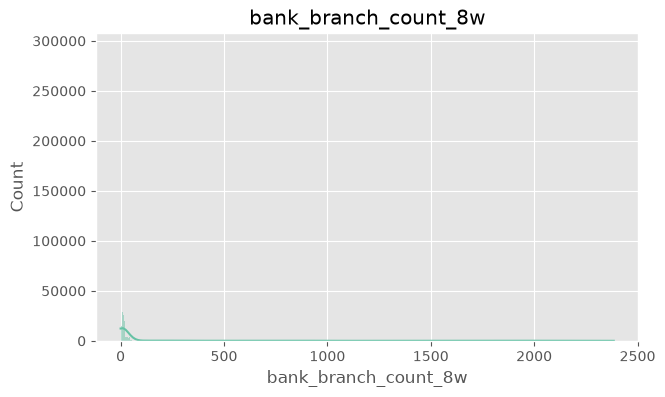

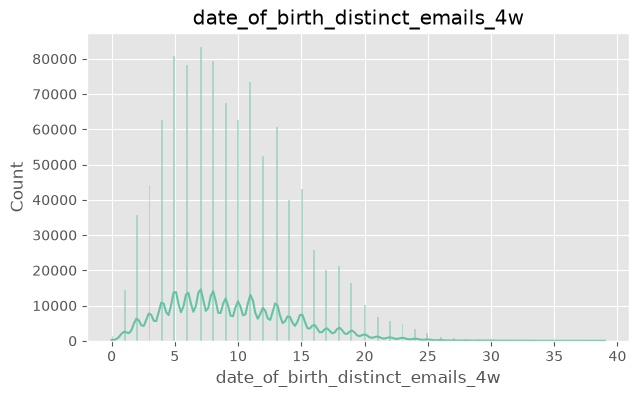

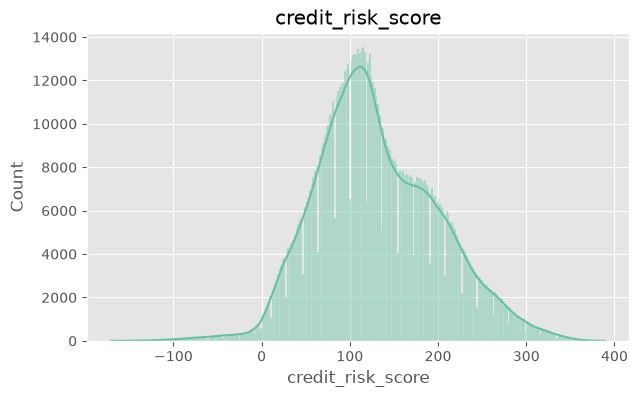

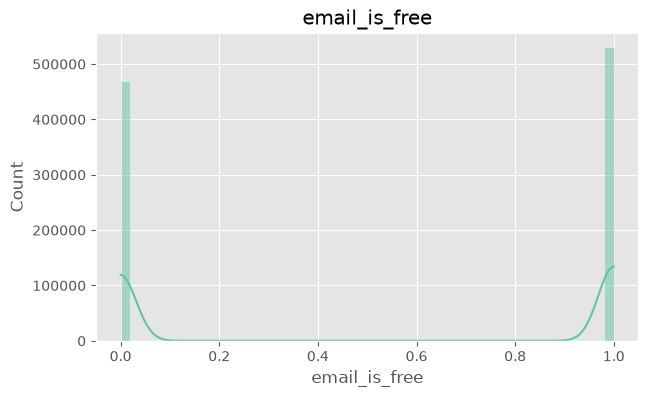

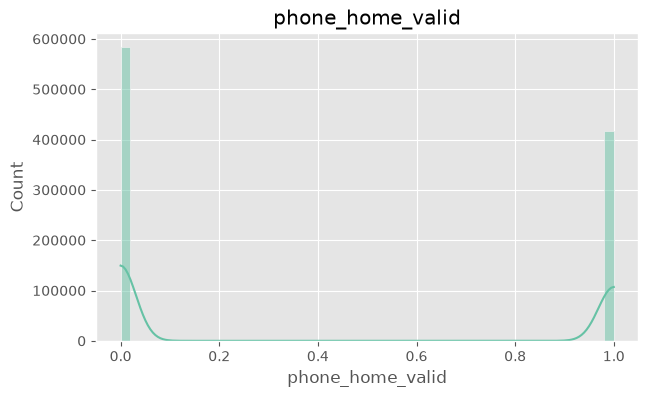

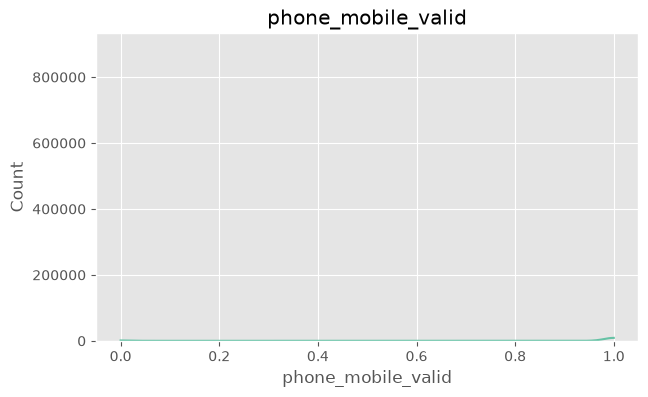

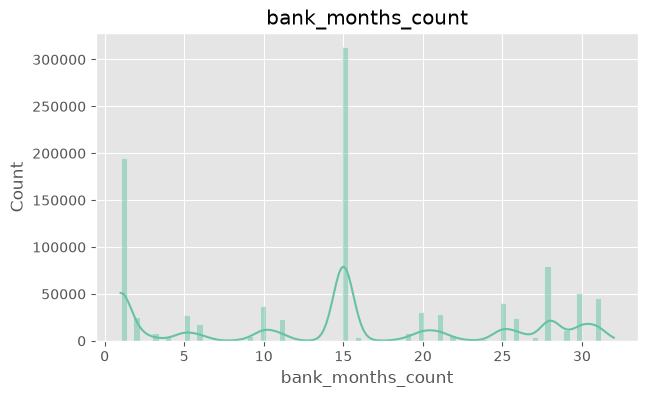

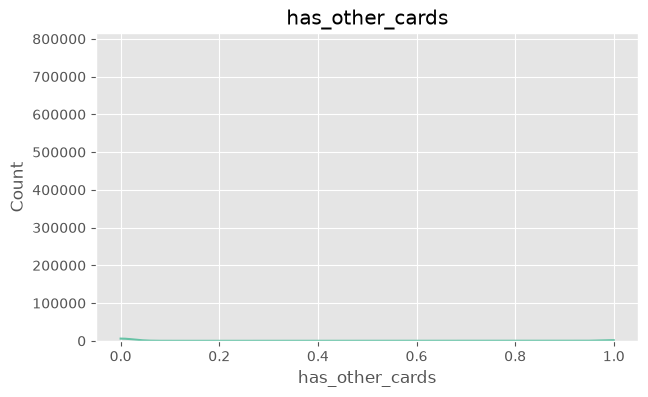

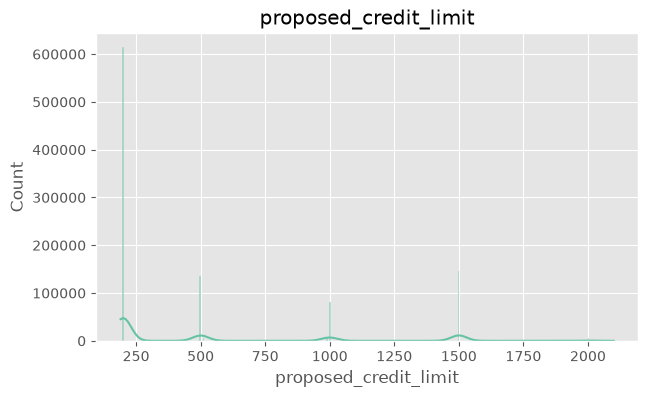

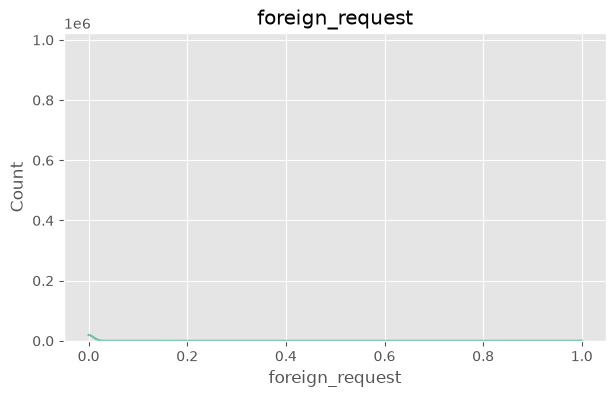

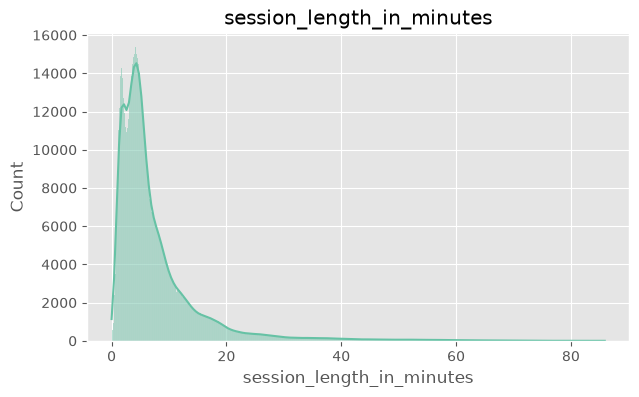

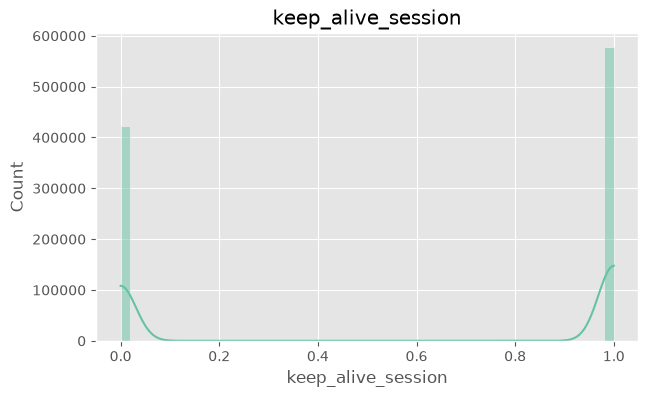

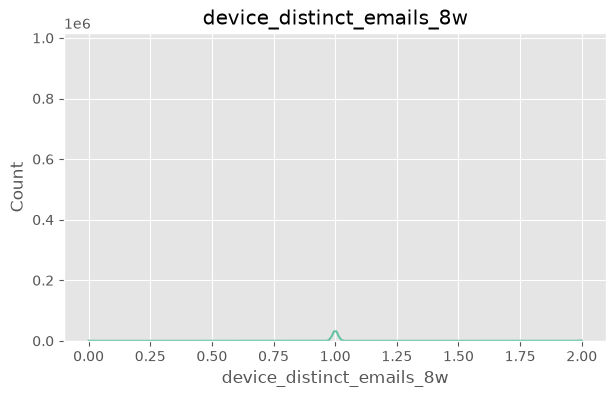

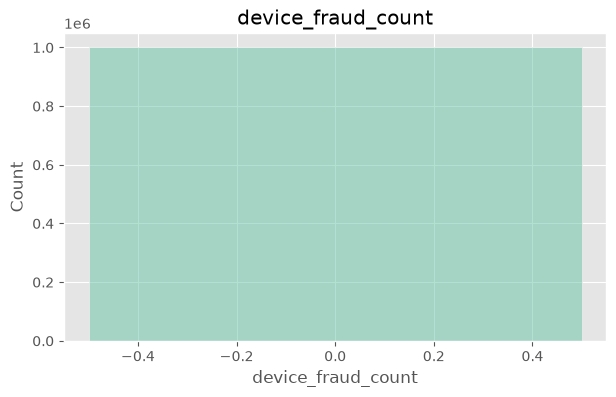

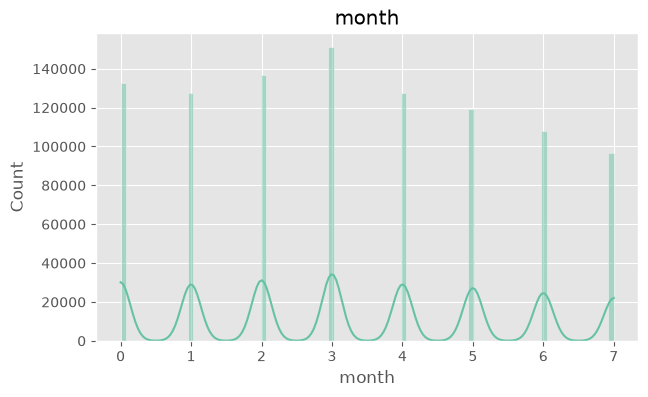

In [10]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [11]:
cat_cols = df.select_dtypes(include="object").columns
print(cat_cols)

Index(['payment_type', 'employment_status', 'housing_status', 'source',
       'device_os'],
      dtype='str')


In [12]:
for col in cat_cols:
    print(col)
    print(df[col].value_counts())
    print()

payment_type
payment_type
AB    370554
AA    258249
AC    252071
AD    118837
AE       289
Name: count, dtype: int64

employment_status
employment_status
CA    730252
CB    138288
CF     44034
CC     37758
CD     26522
CE     22693
CG       453
Name: count, dtype: int64

housing_status
housing_status
BC    372143
BB    260965
BA    169675
BE    169135
BD     26161
BF      1669
BG       252
Name: count, dtype: int64

source
source
INTERNET    992952
TELEAPP       7048
Name: count, dtype: int64

device_os
device_os
other        342728
linux        332712
windows      263506
macintosh     53826
x11            7228
Name: count, dtype: int64



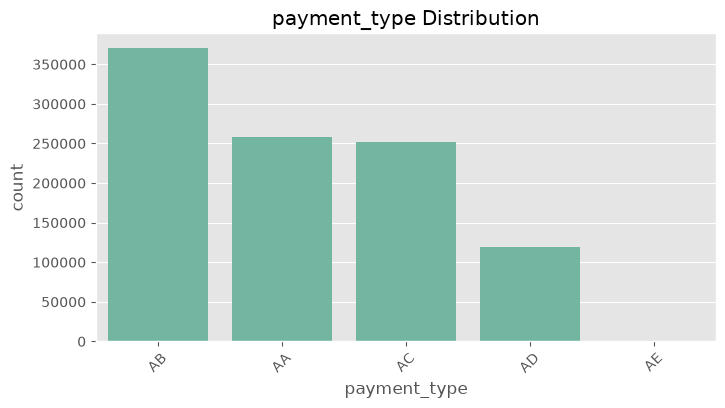

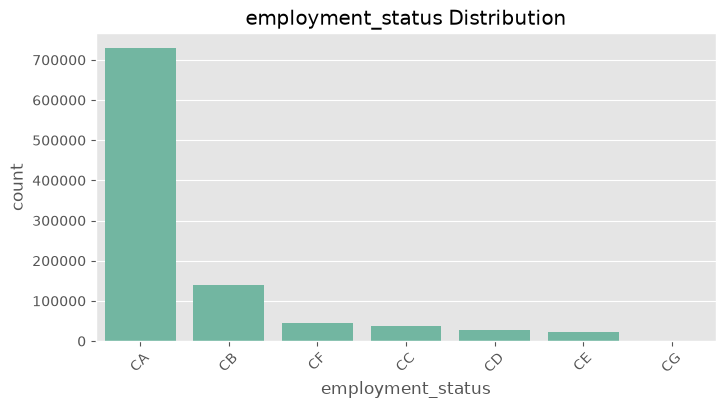

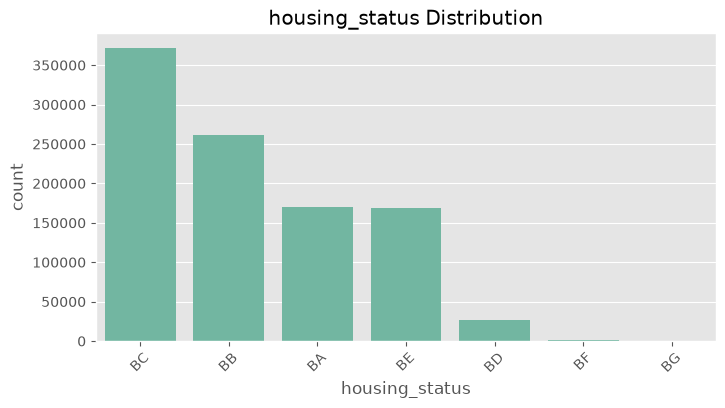

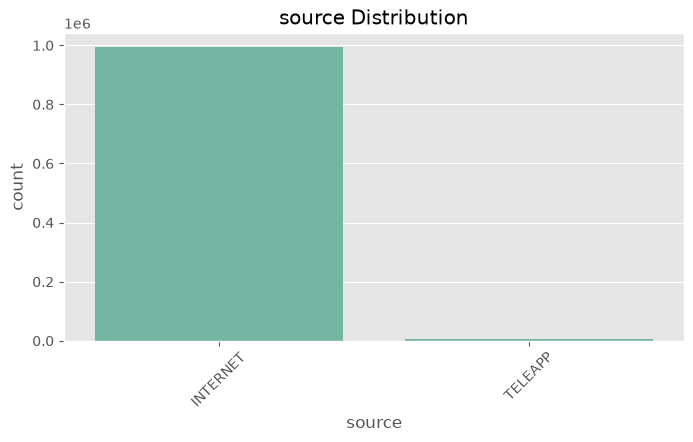

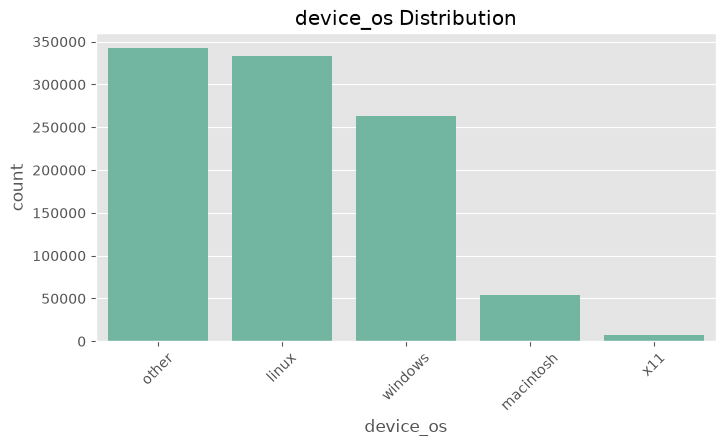

In [13]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df,x=col,order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

In [14]:
corr = df.corr(numeric_only=True)
corr

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
fraud_bool,1.000000,0.045079,-0.036720,-0.010663,0.033569,0.062959,0.000567,-0.024524,0.005212,-0.016892,-0.011183,-0.011536,-0.011577,-0.043224,0.070594,0.027758,-0.035128,-0.013180,0.016733,-0.035156,0.068907,0.016885,0.008978,-0.050296,0.036536,NaN,0.013250
income,0.045079,1.000000,-0.038519,0.016638,-0.036871,0.125822,-0.015877,0.059046,-0.080581,-0.096431,-0.101269,-0.106333,0.007474,-0.062348,0.171253,-0.024900,0.024938,0.014979,-0.035512,0.086861,0.108868,0.011452,-0.055912,-0.043584,-0.011233,NaN,0.116479
name_email_similarity,-0.036720,-0.038519,1.000000,-0.006050,0.050101,-0.048902,-0.007736,0.029040,0.025114,0.024881,0.035221,0.039968,-0.001470,0.022994,0.049248,-0.066897,-0.002931,0.008966,-0.000191,0.011021,0.073159,-0.015224,0.005808,0.014342,-0.018383,NaN,-0.042949
prev_address_months_count,-0.010663,0.016638,-0.006050,1.000000,-0.125395,-0.018202,0.045318,0.000252,-0.009332,-0.003633,-0.000661,-0.002230,-0.017894,0.009185,-0.002480,-0.019125,-0.016508,-0.008691,0.000302,-0.021808,-0.006778,0.010327,0.025320,0.018403,0.009923,NaN,0.005713
current_address_months_count,0.033569,-0.036871,0.050101,-0.125395,1.000000,0.142375,-0.057420,0.057030,0.046854,0.027078,0.018578,0.025924,0.053936,-0.174462,0.094979,-0.079367,0.128573,-0.088076,0.049799,0.060186,0.130314,-0.012320,-0.033283,-0.050480,-0.000745,NaN,-0.024295
customer_age,0.062959,0.125822,-0.048902,-0.018202,0.142375,1.000000,-0.035999,-0.013000,-0.014176,-0.022063,-0.010030,-0.004303,0.048412,-0.420173,0.165993,-0.000357,0.212713,-0.147098,0.002936,0.108743,0.148857,-0.001606,0.025653,-0.024272,0.027769,NaN,0.005694
days_since_request,0.000567,-0.015877,-0.007736,0.045318,-0.057420,-0.035999,1.000000,0.019782,0.000249,0.027968,0.023869,0.017706,-0.018173,0.018731,-0.088093,0.008163,-0.042009,0.005130,0.030410,-0.048861,-0.068670,0.001066,0.050145,0.000337,0.009727,NaN,-0.017938
intended_balcon_amount,-0.024524,0.059046,0.029040,0.000252,0.057030,-0.013000,0.019782,1.000000,0.002251,0.042849,0.064080,0.051407,0.102919,-0.027343,0.002139,-0.014754,0.000019,0.038625,0.036429,0.096676,0.057860,0.007933,0.022264,-0.020689,-0.021219,NaN,-0.043070
zip_count_4w,0.005212,-0.080581,0.025114,-0.009332,0.046854,-0.014176,0.000249,0.002251,1.000000,0.142372,0.201186,0.302955,0.005958,0.126885,-0.102431,0.021731,-0.035661,0.012122,0.046496,-0.015015,-0.011651,0.017212,0.039596,0.022283,0.021112,NaN,-0.287203
velocity_6h,-0.016892,-0.096431,0.024881,-0.003633,0.027078,-0.022063,0.027968,0.042849,0.142372,1.000000,0.464003,0.400254,0.020140,0.118752,-0.145055,0.028379,-0.036820,-0.010751,-0.001659,-0.007049,-0.025005,-0.000450,0.054405,0.002797,0.031079,NaN,-0.409148


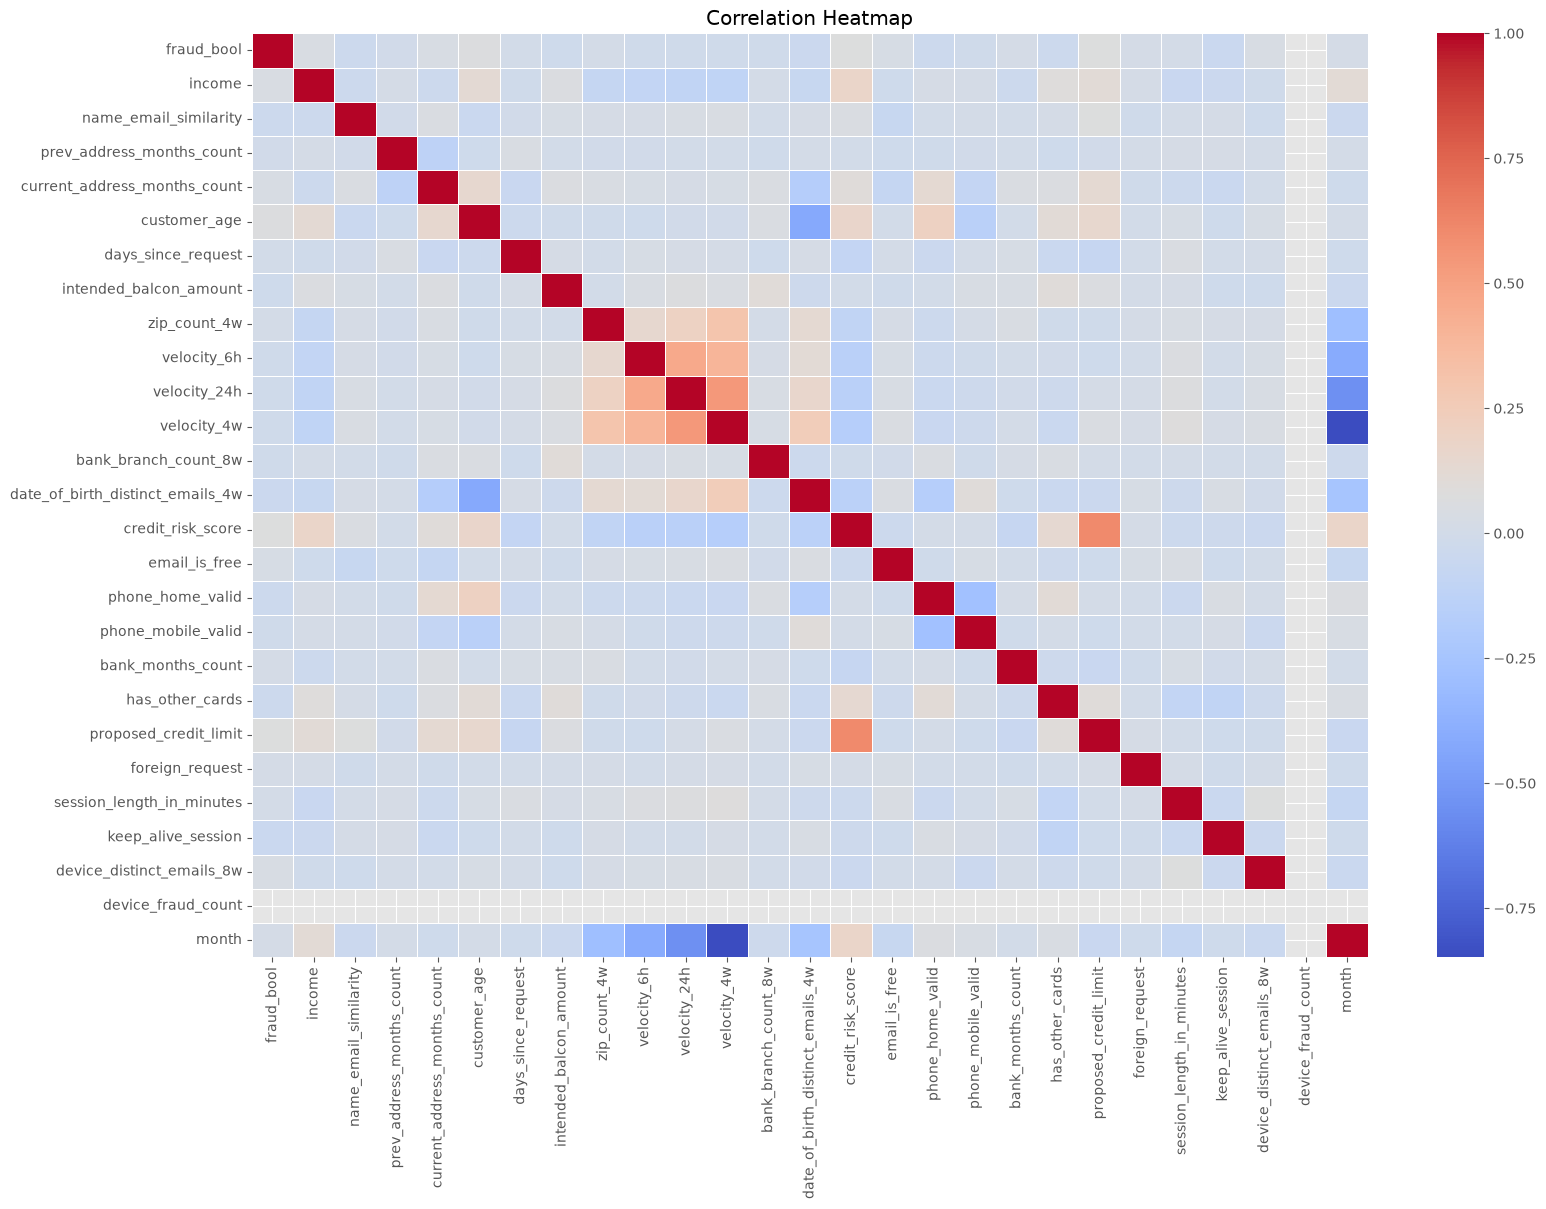

In [15]:
plt.figure(figsize=(18,12))
sns.heatmap(corr,cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
corr["fraud_bool"].sort_values(ascending=False)

fraud_bool                          1.000000
credit_risk_score                   0.070594
proposed_credit_limit               0.068907
customer_age                        0.062959
income                              0.045079
device_distinct_emails_8w           0.036536
current_address_months_count        0.033569
email_is_free                       0.027758
foreign_request                     0.016885
bank_months_count                   0.016733
month                               0.013250
session_length_in_minutes           0.008978
zip_count_4w                        0.005212
days_since_request                  0.000567
prev_address_months_count          -0.010663
velocity_24h                       -0.011183
velocity_4w                        -0.011536
bank_branch_count_8w               -0.011577
phone_mobile_valid                 -0.013180
velocity_6h                        -0.016892
intended_balcon_amount             -0.024524
phone_home_valid                   -0.035128
has_other_

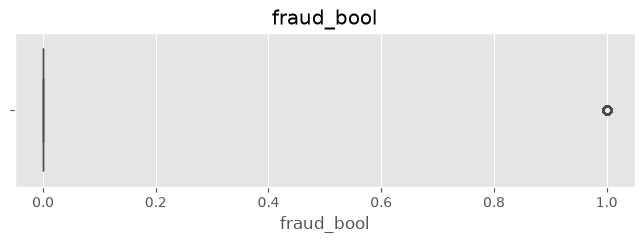

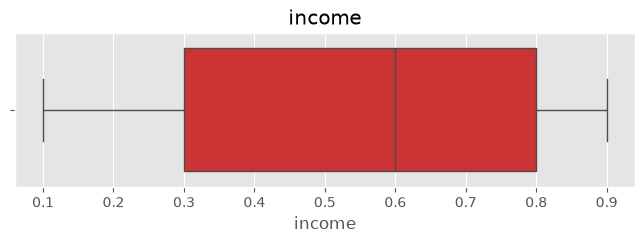

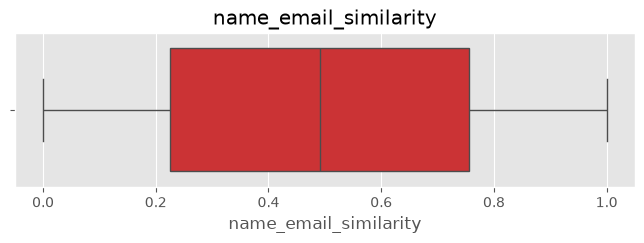

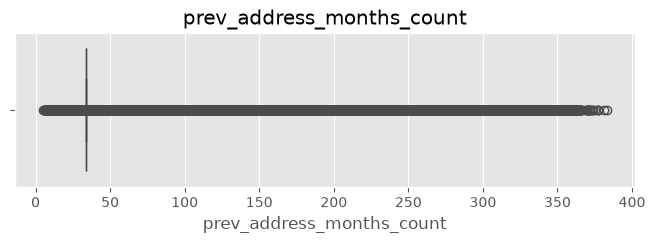

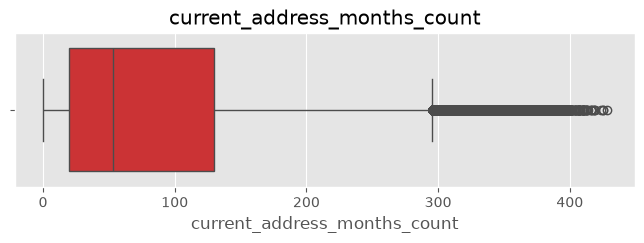

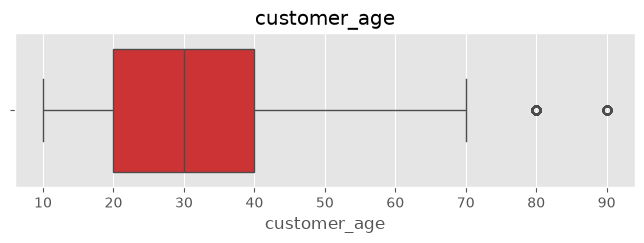

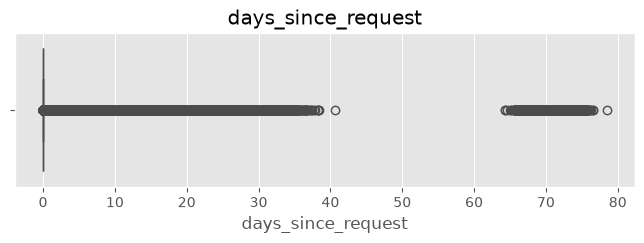

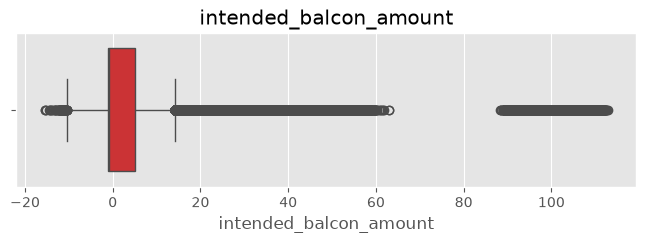

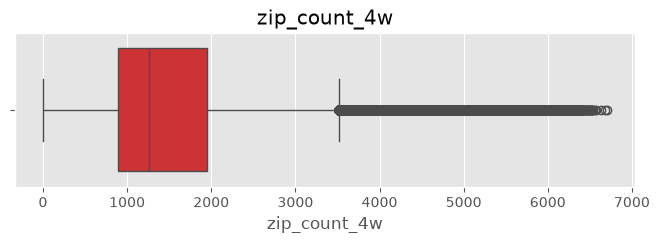

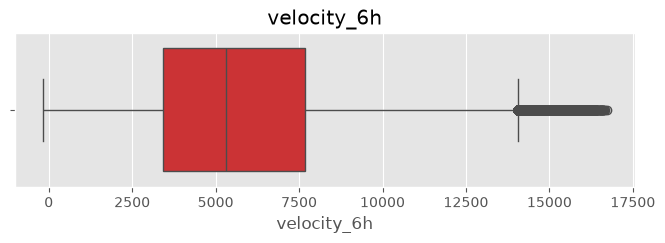

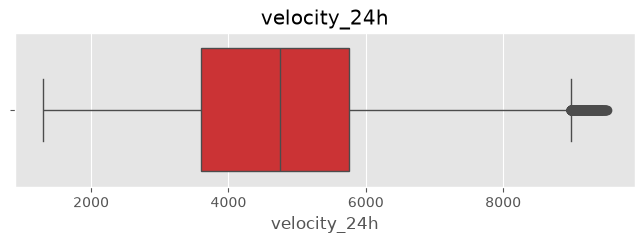

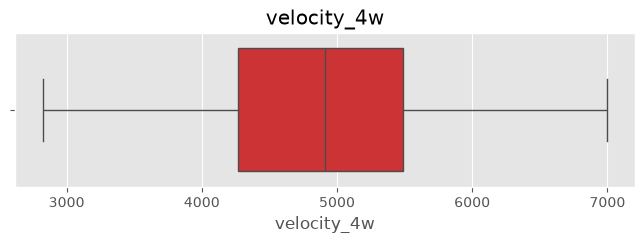

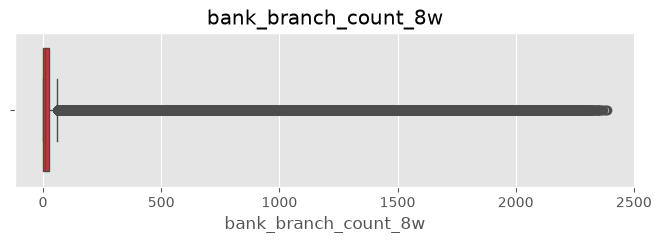

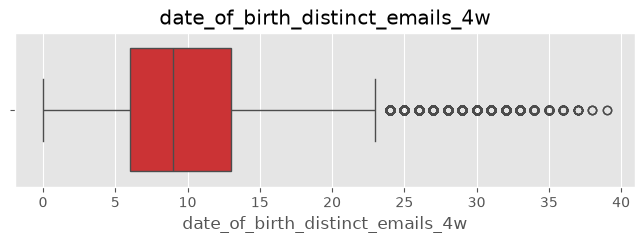

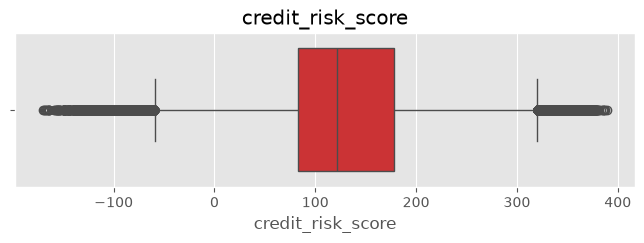

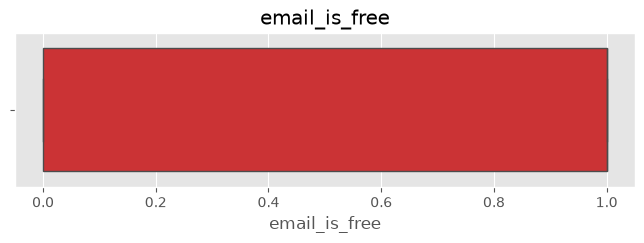

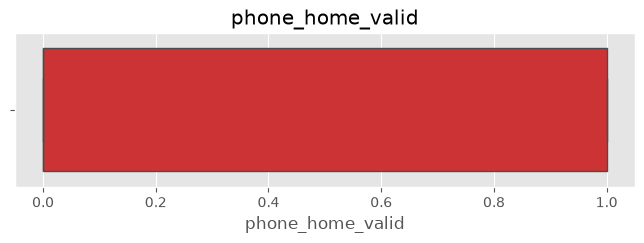

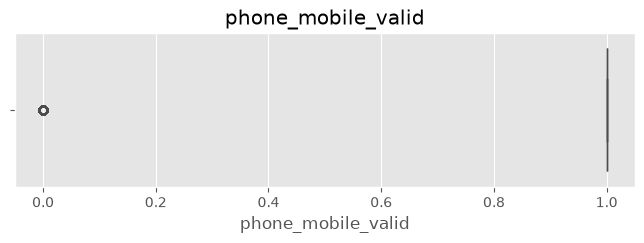

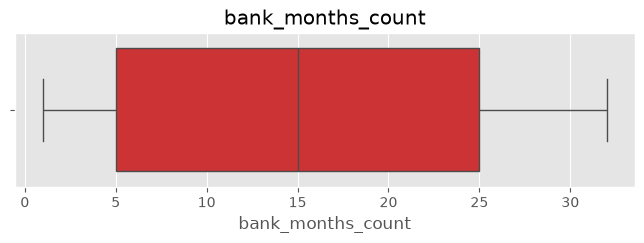

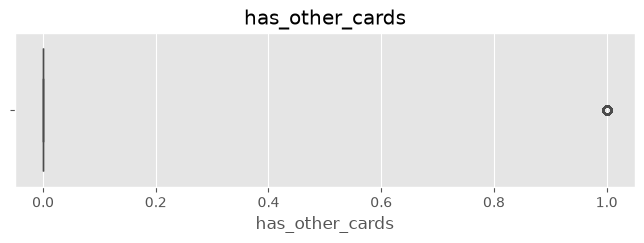

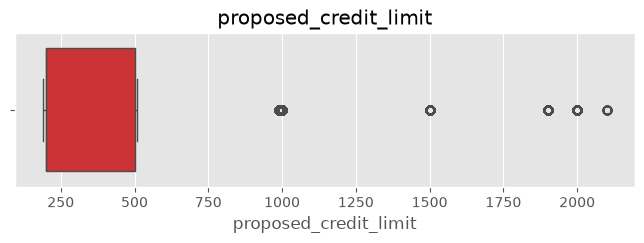

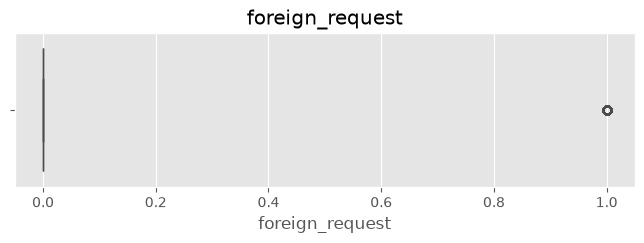

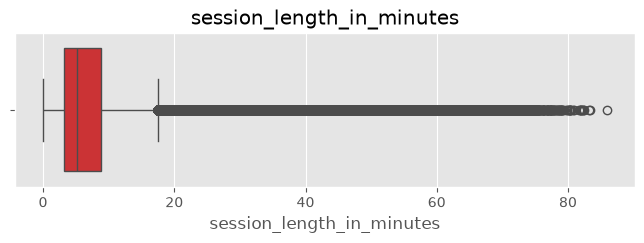

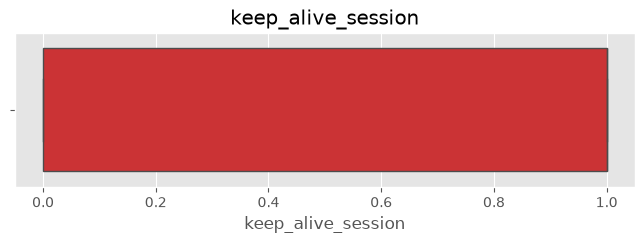

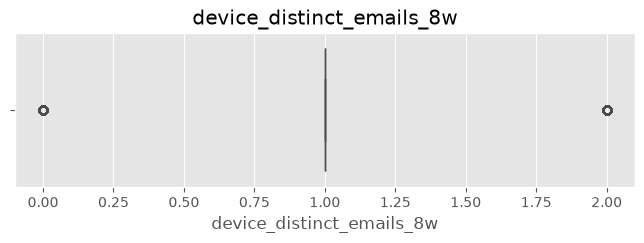

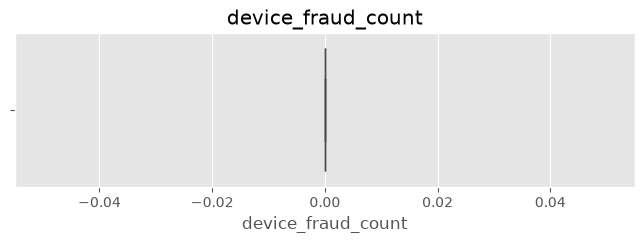

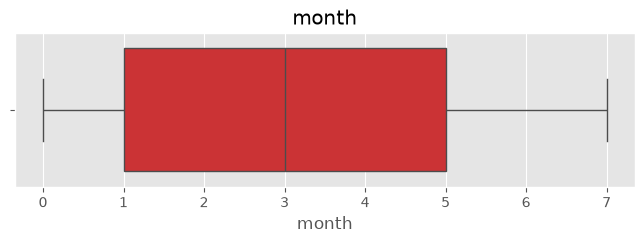

In [33]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col],palette="Set1")
    plt.title(col)
    plt.show()

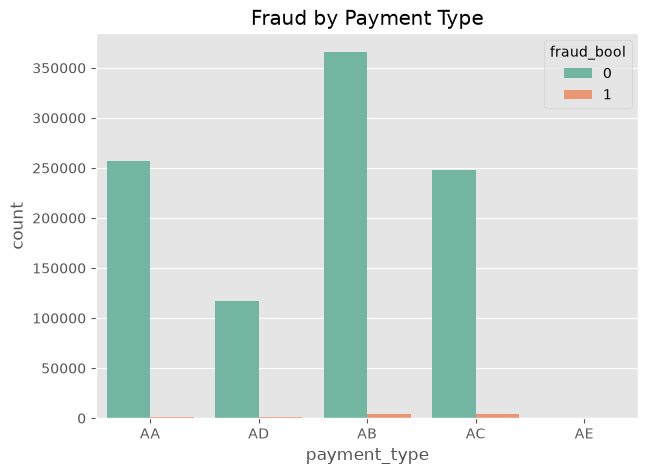

In [18]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="payment_type",hue="fraud_bool")
plt.title("Fraud by Payment Type")
plt.show()

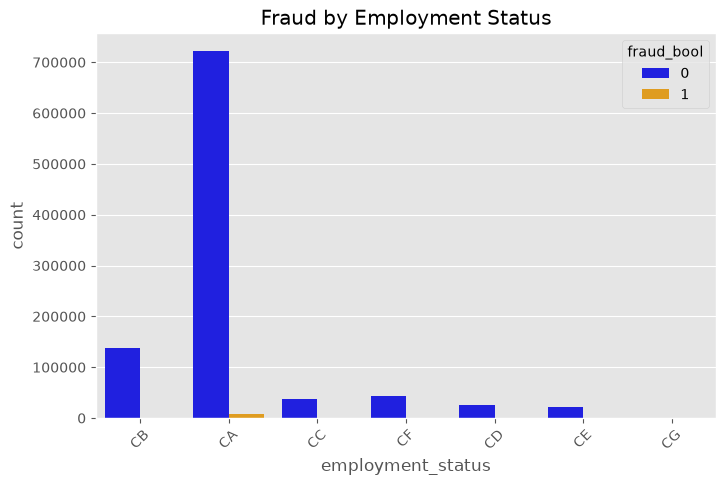

In [23]:
plt.figure(figsize=(8,5))
color_map = {0: "blue", 1: "orange"}
sns.countplot(data=df,x="employment_status",hue="fraud_bool",palette=color_map)
plt.xticks(rotation=45)
plt.title("Fraud by Employment Status")
plt.show()

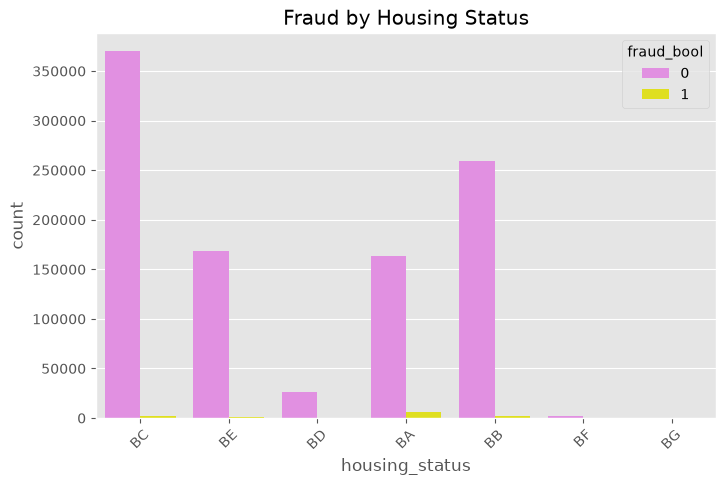

In [27]:
plt.figure(figsize=(8,5))
color_map = {0: "violet", 1: "yellow"}
sns.countplot(data=df,x="housing_status",hue="fraud_bool",palette=color_map)
plt.xticks(rotation=45)
plt.title("Fraud by Housing Status")
plt.show()

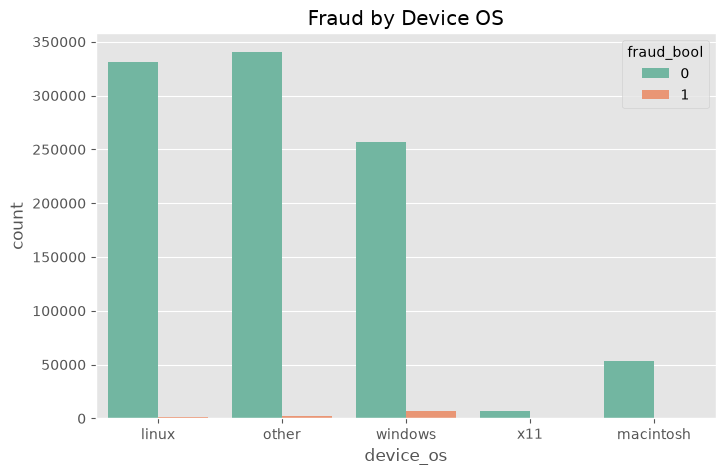

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="device_os",hue="fraud_bool")
plt.title("Fraud by Device OS")
plt.show()

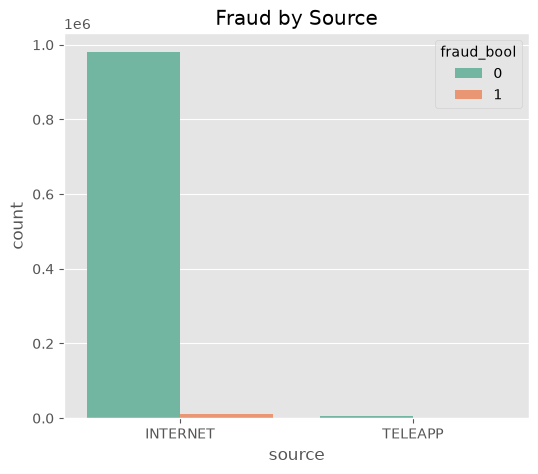

In [29]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x="source",hue="fraud_bool")
plt.title("Fraud by Source")
plt.show()

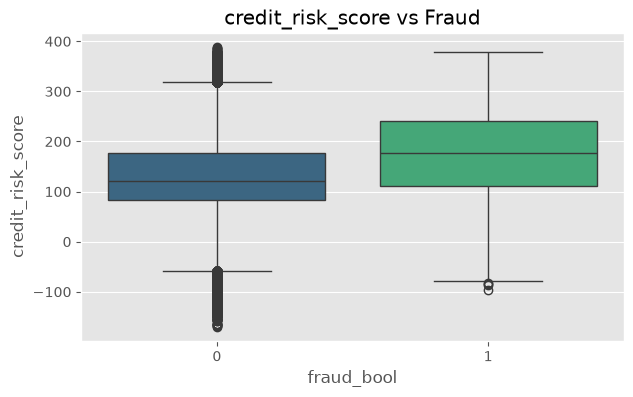

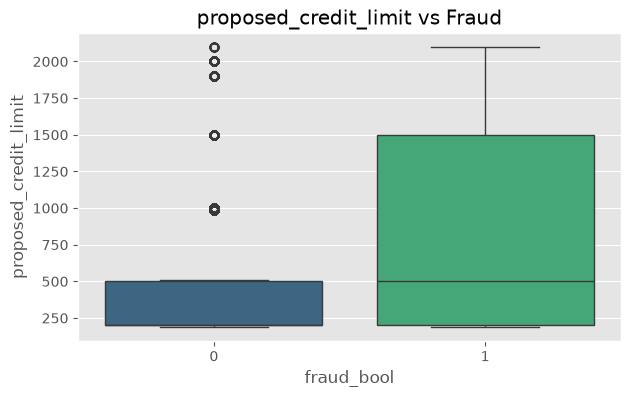

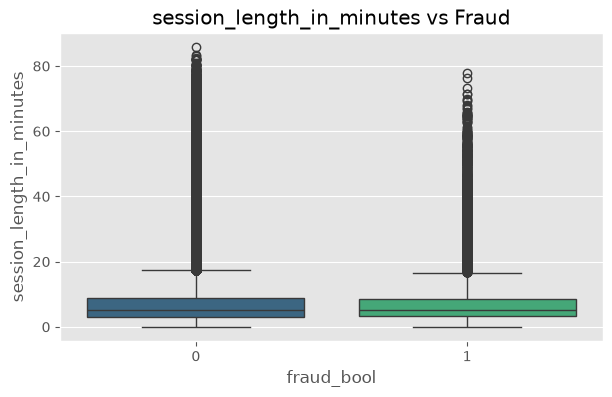

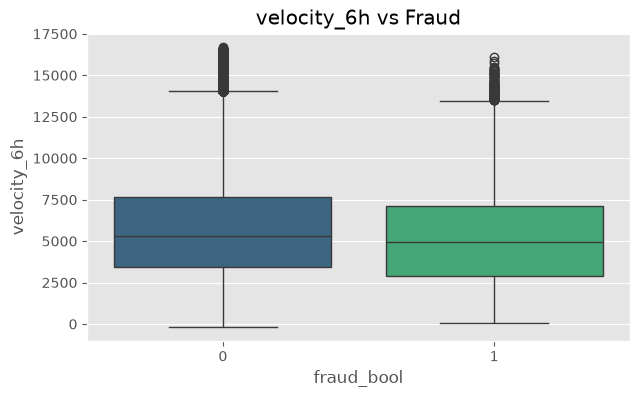

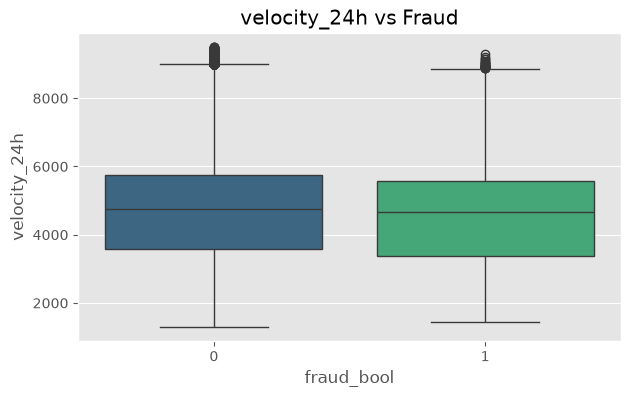

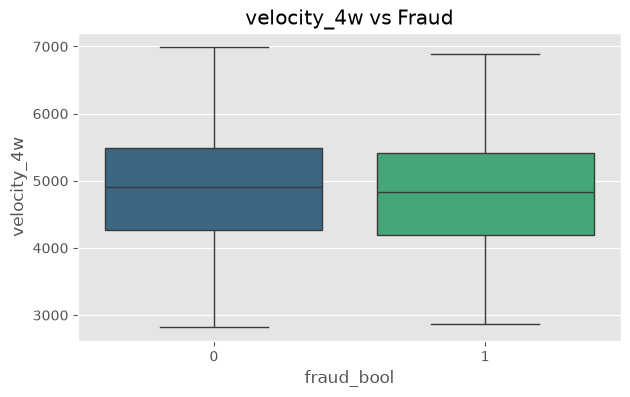

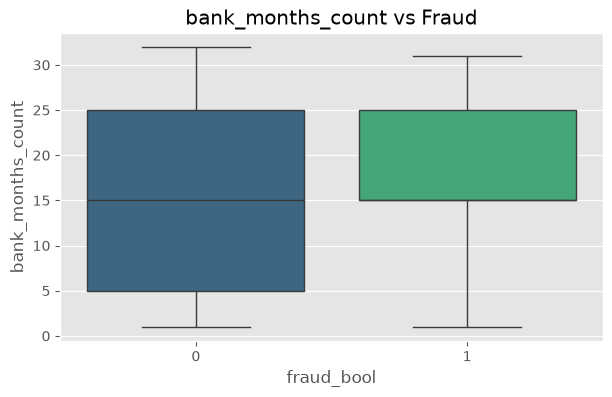

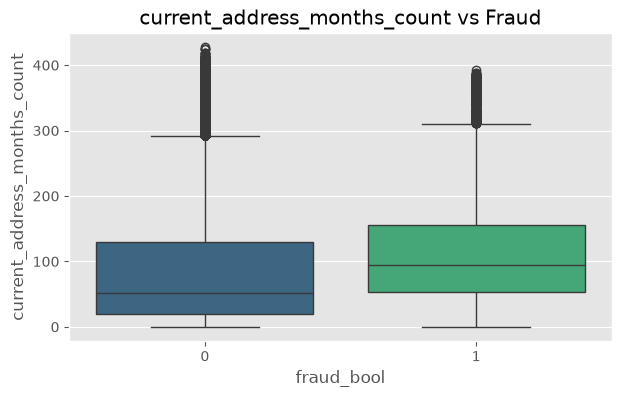

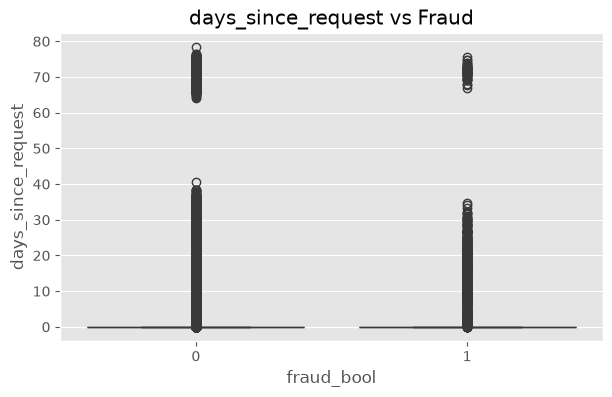

In [32]:
#fraud analysis for numerical features
important_num_cols = ["credit_risk_score","proposed_credit_limit","session_length_in_minutes",
    "velocity_6h","velocity_24h","velocity_4w","bank_months_count","current_address_months_count",
    "days_since_request"]
for col in important_num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df,x="fraud_bool",y=col,palette="viridis")
    plt.title(f"{col} vs Fraud")
    plt.show()

## Summary
Loaded the cleaned dataset generated from the data cleaning phase.
Examined the dataset structure, dimensions, and feature types.
Generated descriptive statistics for both numerical and categorical variables.
Analyzed the distribution of the target variable (fraud_bool) and observed the class imbalance between fraudulent and non-fraudulent transactions.
Explored the distribution of all numerical features using histograms.
Analyzed categorical feature distributions using count plots.
Computed and visualized the correlation matrix to understand relationships among numerical variables.
Performed outlier analysis using boxplots.
Compared fraudulent and non-fraudulent transactions across key categorical features, including:
Payment Type
Employment Status
Housing Status
Device Operating System
Transaction Source
Compared fraud and non-fraud transactions across important numerical features such as:
Credit Risk Score
Proposed Credit Limit
Session Length
Transaction Velocity (6h, 24h, and 4w)
Bank Months Count
Current Address Months Count
Days Since Request
Key Observations
The dataset is highly imbalanced, with fraudulent transactions representing only a small proportion of the total records.
Most numerical variables exhibit skewed distributions and contain noticeable outliers.
Several numerical features show meaningful differences between fraudulent and legitimate transactions.
Categorical variables such as payment type, device operating system, and employment status display different fraud patterns across categories.
The correlation analysis indicates that no severe multicollinearity exists among the majority of features.
The exploratory analysis provides valuable insights that will guide feature engineering, encoding, class balancing, and machine learning model development.
Outcome
The dataset has been thoroughly explored and is now ready for the next preprocessing stage, Encoding, where categorical variables will be converted into machine-learning-compatible numerical representations.